In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

In [2]:
# To implement
class DiscretePrior:
    ## Initialise with the beta parameters
    def __init__(self, num_values):
        # initialise uniformly the belief
        self.num_values = num_values
        self.belief = np.ones(num_values) / num_values 
        self.bias_values = np.linspace(0, 1, num_values)

    ## Update the belief when you see a new observation
    def update(self, success):
        if success:
            likelihood = self.bias_values
        else:
            likelihood = 1 - self.bias_values

        self.belief = self.belief * likelihood
        self.belief = self.belief / np.sum(self.belief)

    def mean(self):
        return np.sum(self.bias_values * self.belief)


In [3]:
# To implement
class BetaConjugatePrior:
    ## Initialise with the beta parameters
    def __init__(self, alpha, beta):
        self.alpha = alpha
        self.beta = beta

    ## Update the belief when you see a new observation
    def update(self, success):
        k = 1 if success else 0
        self.alpha = self.alpha + k
        self.beta = self.beta + (1 - k)

    def mean(self):
        return self.alpha / (self.alpha + self.beta)

In [4]:
def plot_categorical_distribution(belief):
    x = np.arange(len(belief.bias_values)) / len(belief.bias_values)
    width = 1/len(belief.bias_values)
    
    plt.bar(x + width/2, belief.belief, width=width, alpha=0.8, label="Discrete belief", color="red")


In [5]:
def plot_beta_distribution(belief, true_param):
    x = np.linspace(0, 1, 20)    
    beta_pdf = stats.beta.pdf(x, belief.alpha, belief.beta)
    # Normalize the Beta PDF so that it sums to 1 over discrete points
    beta_pdf *= np.sum(1 / np.trapz(beta_pdf, x))

    plt.plot(x, beta_pdf, label="Beta belief")
    plt.axvline(x = true_param, color = 'b', linestyle=":", label="True Bias")

Initial beliefs


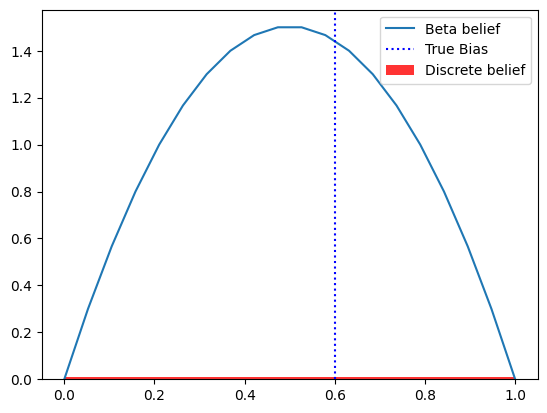

Tosses: 21
Alpha: 13 Beta: 11
Beta distribution mean: 0.542
Discrete distribution mean: 0.545


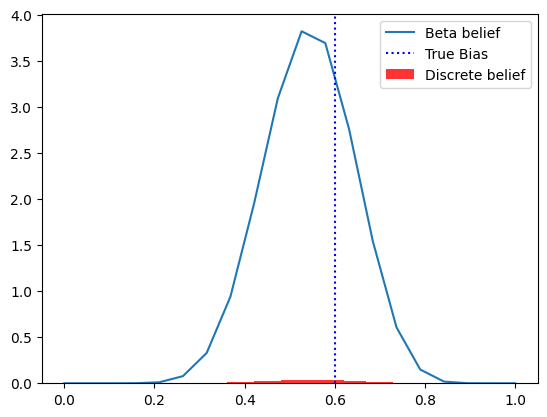

Tosses: 41
Alpha: 25 Beta: 19
Beta distribution mean: 0.568
Discrete distribution mean: 0.571


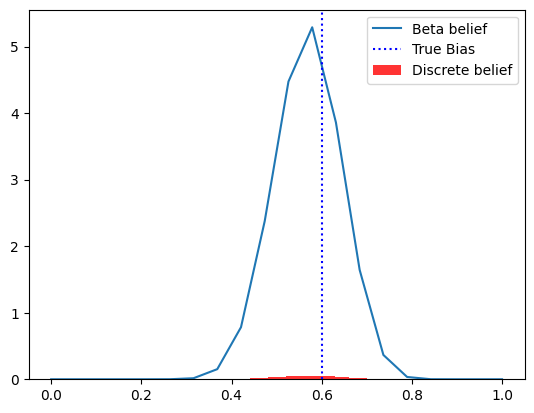

Tosses: 61
Alpha: 40 Beta: 24
Beta distribution mean: 0.625
Discrete distribution mean: 0.629


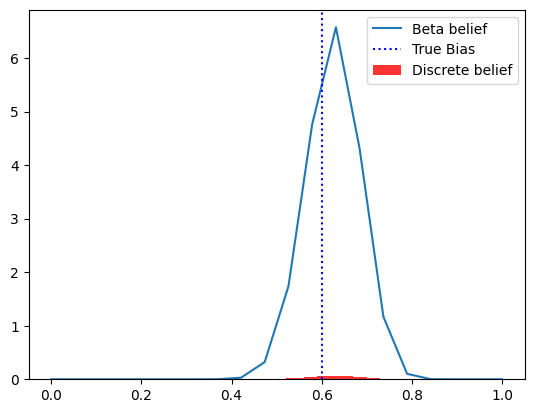

Tosses: 81
Alpha: 51 Beta: 33
Beta distribution mean: 0.607
Discrete distribution mean: 0.610


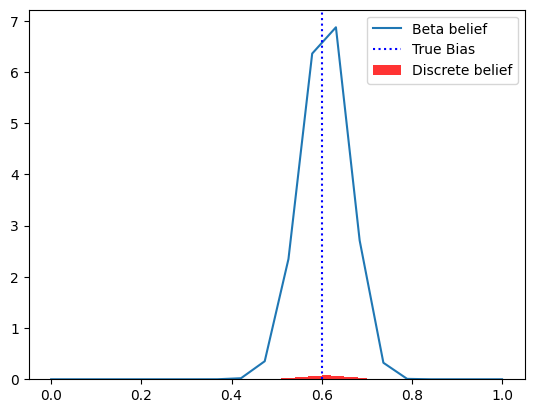

Tosses: 101
Alpha: 62 Beta: 42
Beta distribution mean: 0.596
Discrete distribution mean: 0.598


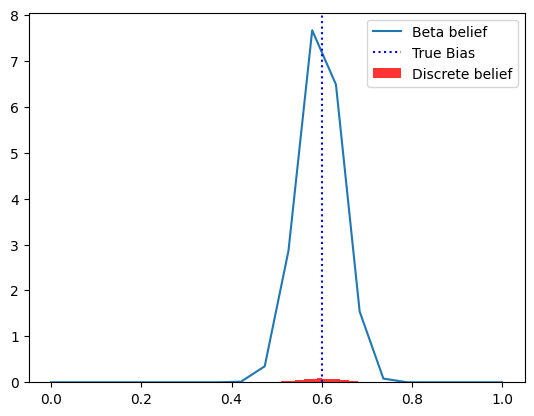

Tosses: 121
Alpha: 68 Beta: 56
Beta distribution mean: 0.548
Discrete distribution mean: 0.549


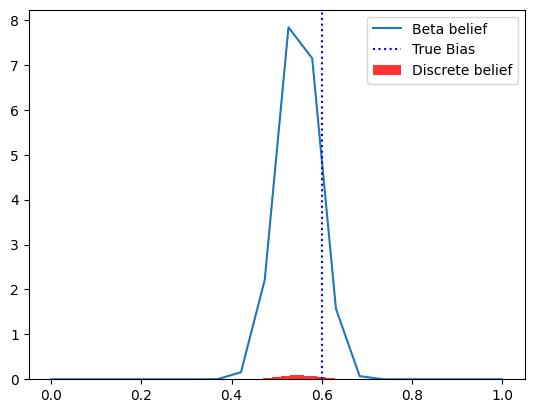

Tosses: 141
Alpha: 80 Beta: 64
Beta distribution mean: 0.556
Discrete distribution mean: 0.556


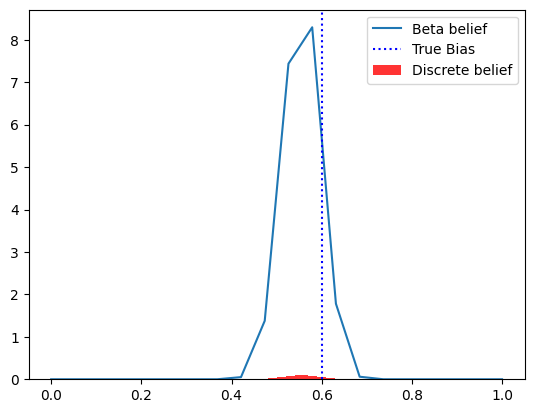

Tosses: 161
Alpha: 92 Beta: 72
Beta distribution mean: 0.561
Discrete distribution mean: 0.562


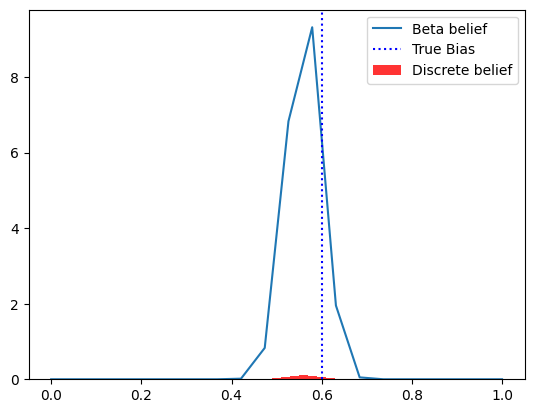

Tosses: 181
Alpha: 101 Beta: 83
Beta distribution mean: 0.549
Discrete distribution mean: 0.549


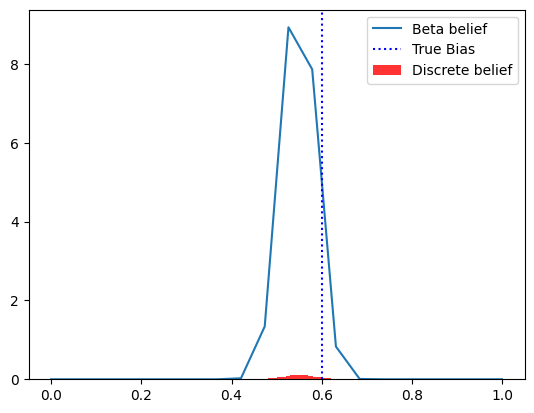

Tosses: 201
Alpha: 113 Beta: 91
Beta distribution mean: 0.554
Discrete distribution mean: 0.554


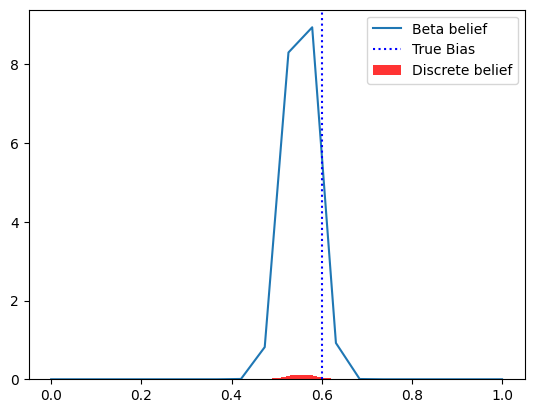

Tosses: 221
Alpha: 124 Beta: 100
Beta distribution mean: 0.554
Discrete distribution mean: 0.554


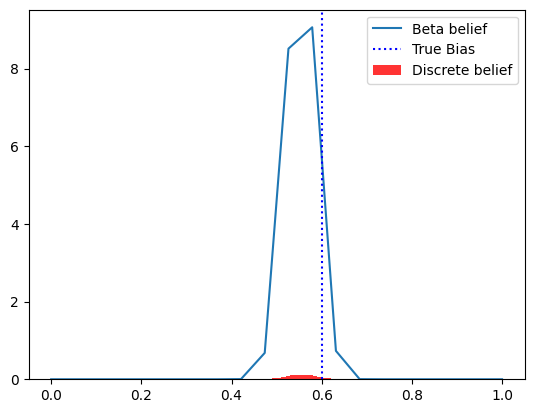

Tosses: 241
Alpha: 139 Beta: 105
Beta distribution mean: 0.570
Discrete distribution mean: 0.570


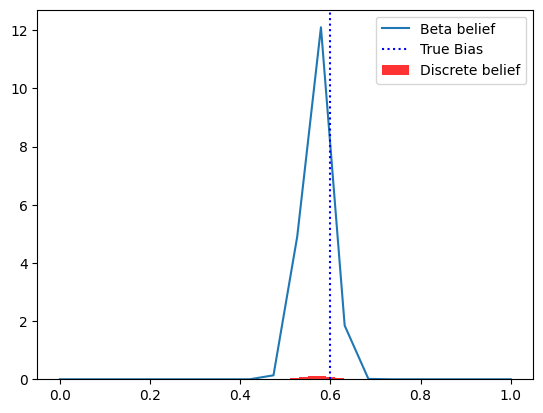

Tosses: 261
Alpha: 154 Beta: 110
Beta distribution mean: 0.583
Discrete distribution mean: 0.584


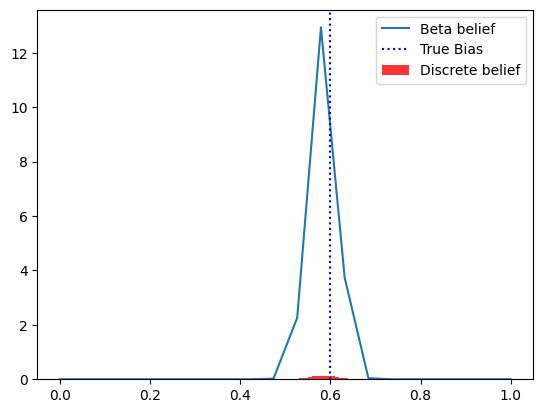

Tosses: 281
Alpha: 166 Beta: 118
Beta distribution mean: 0.585
Discrete distribution mean: 0.585


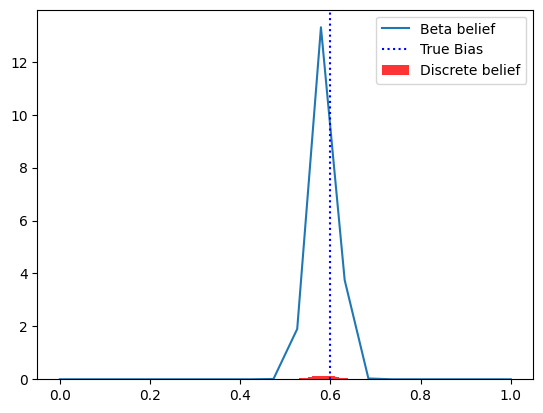

Tosses: 301
Alpha: 177 Beta: 127
Beta distribution mean: 0.582
Discrete distribution mean: 0.583


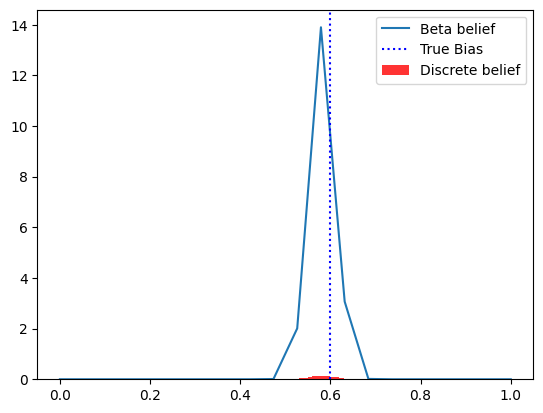

Tosses: 321
Alpha: 192 Beta: 132
Beta distribution mean: 0.593
Discrete distribution mean: 0.593


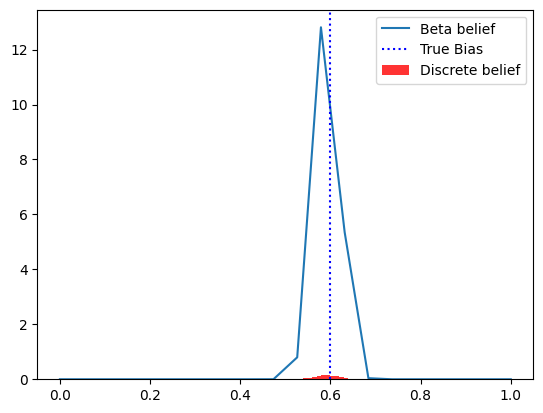

Tosses: 341
Alpha: 201 Beta: 143
Beta distribution mean: 0.584
Discrete distribution mean: 0.585


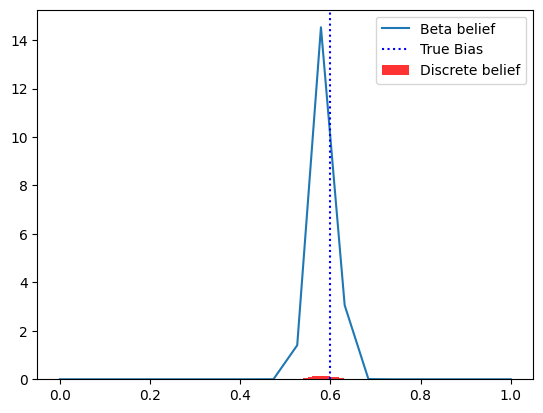

Tosses: 361
Alpha: 214 Beta: 150
Beta distribution mean: 0.588
Discrete distribution mean: 0.588


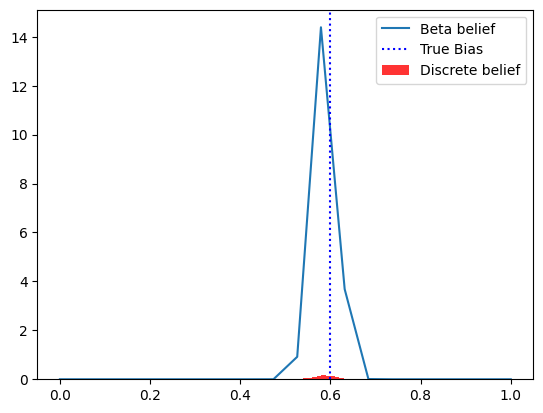

Tosses: 381
Alpha: 223 Beta: 161
Beta distribution mean: 0.581
Discrete distribution mean: 0.581


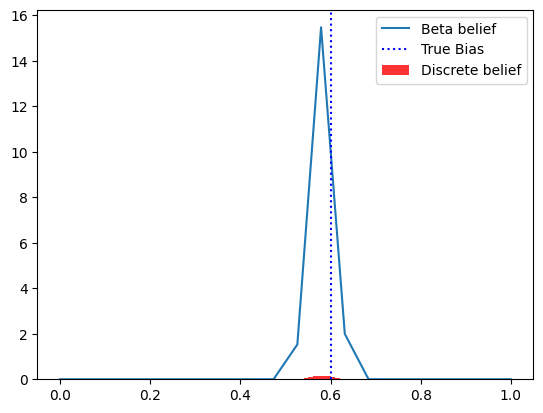

Tosses: 401
Alpha: 234 Beta: 170
Beta distribution mean: 0.579
Discrete distribution mean: 0.580


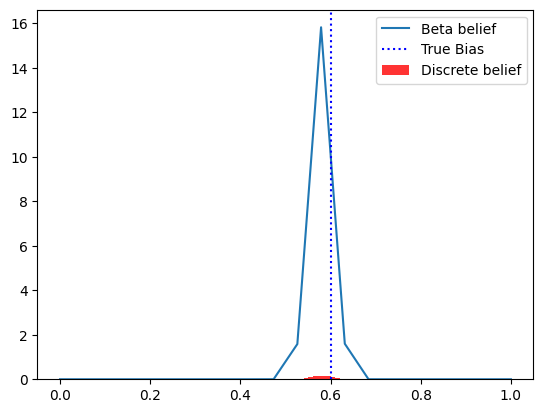

Tosses: 421
Alpha: 249 Beta: 175
Beta distribution mean: 0.587
Discrete distribution mean: 0.588


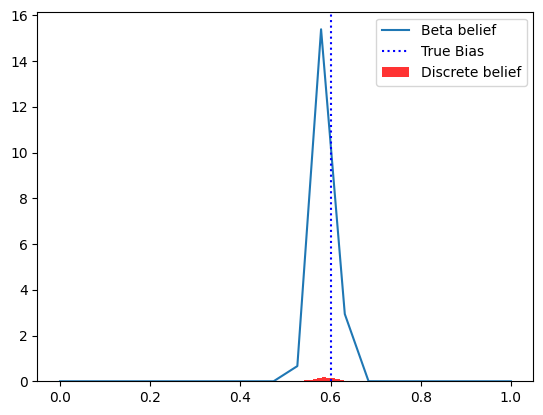

Tosses: 441
Alpha: 261 Beta: 183
Beta distribution mean: 0.588
Discrete distribution mean: 0.588


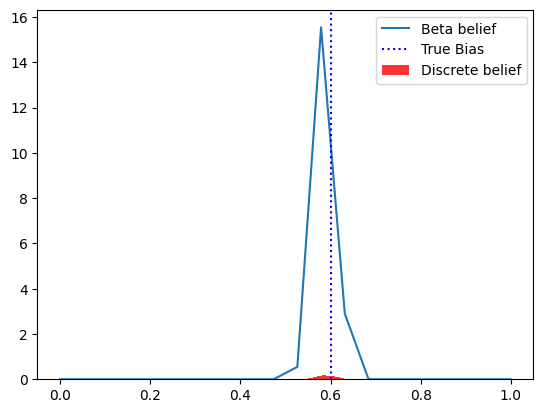

Tosses: 461
Alpha: 273 Beta: 191
Beta distribution mean: 0.588
Discrete distribution mean: 0.589


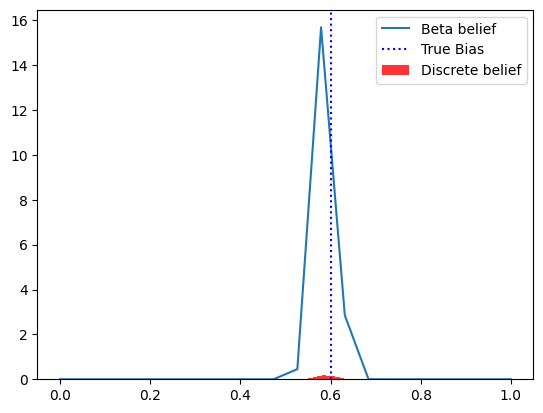

Tosses: 481
Alpha: 287 Beta: 197
Beta distribution mean: 0.593
Discrete distribution mean: 0.593


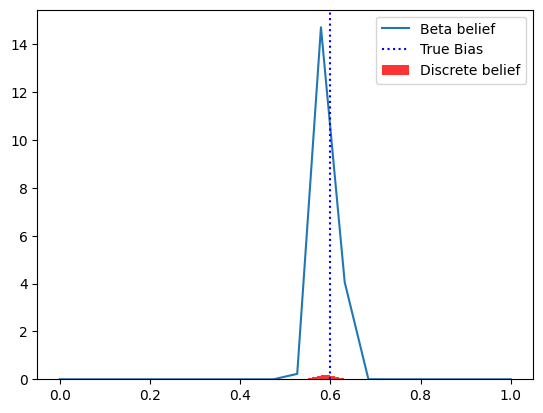

Tosses: 501
Alpha: 300 Beta: 204
Beta distribution mean: 0.595
Discrete distribution mean: 0.596


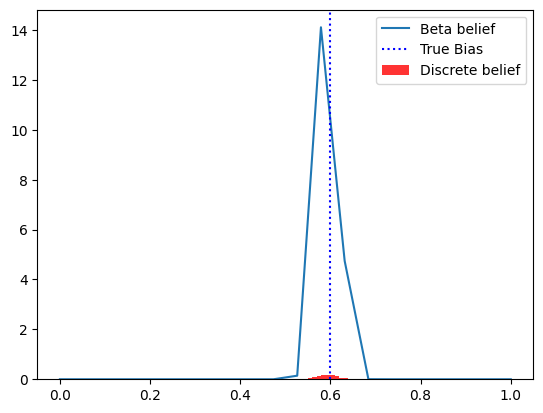

In [6]:
T = 500  # number of time steps
n = 100 # Number of values for the discrete prior
true_bias = 0.6 # probability of heads
alpha_0 = beta_0 = 2 # initial belief parameters
discrete_belief = DiscretePrior(n)
beta_belief = BetaConjugatePrior(alpha_0, beta_0)

print("Initial beliefs")
plot_categorical_distribution(discrete_belief)
plot_beta_distribution(beta_belief, true_bias)
plt.legend()
plt.show()

for t in range(1, T+1):
    # sample from the n=1 binomial (i.e. Bernoulli) distribution
    # equivalent to performing one coin toss
    is_head = np.random.binomial(1, true_bias) == 1
    ## update the belief
    discrete_belief.update(is_head)
    beta_belief.update(is_head)
    
    if t % 20 == 0:
        print("Tosses:", t+1)
        print("Alpha:", beta_belief.alpha, "Beta:", beta_belief.beta)
        print(f"Beta distribution mean: {beta_belief.mean():.3f}")
        print(f"Discrete distribution mean: {discrete_belief.mean():.3f}")

        plot_categorical_distribution(discrete_belief)
        plot_beta_distribution(beta_belief, true_bias)
        plt.legend()
        plt.show()
